# Notebook interactivo documentado
***Descripcion:*** Manipular, analizar y visualizar datos estructurados mediante **NumPy, Pandas y Matplotlib**, integrando información desde bases de datos SQL y exportándola en formatos portables para análisis posterior.

***URL Github:*** https://github.com/gvcabrera/AIMLT2

***Autor:*** Giovanni Cabrera

## Estructura SQL 
Estructura de datos
Nombre del archivo **.sql: sqlite-contenido.sql** 

```sql
CREATE TABLE contenido (
 id_pelicula integer PRIMARY KEY, 
 titulo text, 
 genero text, 
 duracion_minutos integer, 
 calificacion integer, 
 año_lanzamiento integer, 
 plataforma text, 
 tipo text, 
 visualizaciones integer
);


## Generación de datos aleatorios
Se usa script de Python para la generación de datos aleatorios.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sqlalchemy import create_engine

In [7]:
#Listas para valores aleatorios en la tabla
generos = [
    "Acción",
    "Thriller",
    "Drama",
    "Comedia",
    "Ciencia Ficción",
    "Terror",
    "Romance",
    "Aventura"
]

plataformas = [
    "Netflix",
    "Disney+",
    "Prime Video",
    "HBO Max",
    "Vix+",
    "Paramount+",
    "Apple TV+"
]

tipos = [
    "Series",
    "Películas",
    "Documentales",
    "Novelas",
    "Realities"
]

adjetivos = [
    "Dulce", "Oscuro", "Perdido", "Secreto",
    "Eterno", "Lejano","Prohibido", "Invisible", 
    "Misterioso", "Olvidado", "Amado", "Cercano",
    "Oculto", "Poderoso", "Protegido", "Milenario"
]

sustantivos = [
    "Destino", "Imperio", "Horizonte",
    "Portal", "Bosque", "Universo",
    "Planeta", "Juego", "Reino",
    "Oeste", "Buque", "Detective", 
    "Abismo", "Hombre", "Joven",
    "Niño", "Tren", "Paraiso", 
    "Enemigo", "Aliado", "Equipo",
    "Emperador", "Cuento", "Mago"
]

complementos = [
    "en el Tiempo", "de Cristal", "de Impacto",
    "de Fuego", "de las Sombras", "del Amanecer",
    "de la Luna", "del Universo", "del Sol",
    "del Horror", "del Pasado", "del Norte", 
    "del Futuro", "del más allá", "de Agua",
    "de la Luz", "de Aire", "de Tierra"
]

#Se crea un diccionario por cada película, luego se convierte todo a DataFrame
contenidos = []
for i in range(1000):
    #Se genera lista de patrones con sustantivos, adjetivos y complementos para generar titulos de contenidos aleatorios
    patrones = [
        f"{np.random.choice(sustantivos)} {np.random.choice(adjetivos)}",
        f"{np.random.choice(sustantivos)} {np.random.choice(complementos)}",
        f"{np.random.choice(sustantivos)} {np.random.choice(adjetivos)} {np.random.choice(complementos)}"
    ]
    contenidos.append({
        'id_pelicula': (i+1),
        'titulo': np.random.choice(patrones),
        'genero': np.random.choice(generos),
        'duracion_minutos': np.random.randint(90, 180),
        'calificacion': np.random.randint(1, 5),
        'año_lanzamiento': np.random.randint(1990, 2026),
        'plataforma': np.random.choice(plataformas),
        'tipo': np.random.choice(tipos),
        'visualizaciones': np.random.randint(1000, 1000000)
    })

df = pd.DataFrame(contenidos)
df.head()



,id_pelicula,titulo,genero,duracion_minutos,calificacion,año_lanzamiento,plataforma,tipo,visualizaciones
0,1,Tren del Norte,Drama,144,3,1997,Vix+,Novelas,745754
1,2,Enemigo del Amanecer,Comedia,169,1,2022,HBO Max,Películas,70466
2,3,Tren Invisible de Tierra,Comedia,173,2,2011,Disney+,Documentales,770461
3,4,Enemigo Protegido,Terror,158,1,2016,Disney+,Películas,313225
4,5,Abismo Poderoso del Norte,Drama,155,4,2008,Prime Video,Películas,7019


## Registro en BD
Se pobla la tabla con  1,000 registros.

In [8]:
engine = create_engine("sqlite:///AIMLT2.db")

df.to_sql(
    "contenido",
    engine,
    if_exists="replace",
    index=False
)

dfc = pd.read_sql(
    "SELECT * FROM contenido LIMIT 5",
    engine
)

dfc

,id_pelicula,titulo,genero,duracion_minutos,calificacion,año_lanzamiento,plataforma,tipo,visualizaciones
0,1,Tren del Norte,Drama,144,3,1997,Vix+,Novelas,745754
1,2,Enemigo del Amanecer,Comedia,169,1,2022,HBO Max,Películas,70466
2,3,Tren Invisible de Tierra,Comedia,173,2,2011,Disney+,Documentales,770461
3,4,Enemigo Protegido,Terror,158,1,2016,Disney+,Películas,313225
4,5,Abismo Poderoso del Norte,Drama,155,4,2008,Prime Video,Películas,7019


## Generación de archivo CSV

In [9]:
df.to_csv('contenido.csv')
df.head()

,id_pelicula,titulo,genero,duracion_minutos,calificacion,año_lanzamiento,plataforma,tipo,visualizaciones
0,1,Tren del Norte,Drama,144,3,1997,Vix+,Novelas,745754
1,2,Enemigo del Amanecer,Comedia,169,1,2022,HBO Max,Películas,70466
2,3,Tren Invisible de Tierra,Comedia,173,2,2011,Disney+,Documentales,770461
3,4,Enemigo Protegido,Terror,158,1,2016,Disney+,Películas,313225
4,5,Abismo Poderoso del Norte,Drama,155,4,2008,Prime Video,Películas,7019


## Graficar con Matplotlib
Realizar al menos una visualización con Matplotlib.

Text(0, 0.5, 'Plataforma')

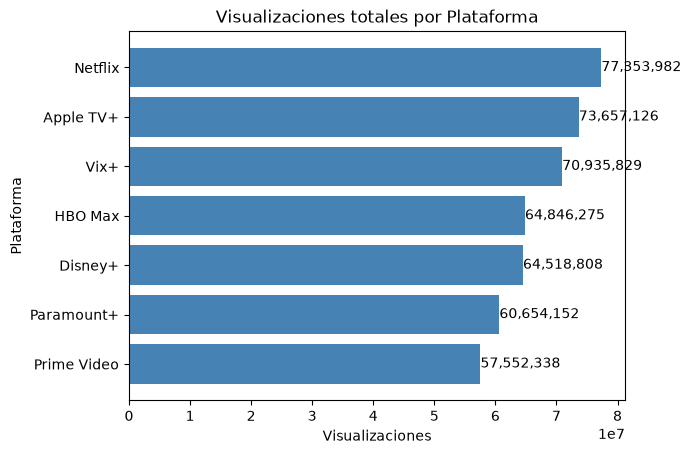

In [10]:
visualizaciones_plataforma = (
    df.groupby("plataforma")["visualizaciones"]
      .sum()      
      .sort_values()
)

barras = plt.barh(
    visualizaciones_plataforma.index,
    visualizaciones_plataforma.values,
    color="steelblue",
    data=visualizaciones_plataforma
)

for barra in barras:
    plt.text(
        barra.get_width(),
        barra.get_y() + barra.get_height() / 2,
        f"{int(barra.get_width()):,}",
        va="center"
    )

plt.title("Visualizaciones totales por Plataforma")
plt.xlabel("Visualizaciones")
plt.ylabel("Plataforma")

